In [42]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
import os
import pandas as pd

dataset_path = "/kaggle/input/datasets/jannatulferdaues/medicinal-flower-dataset/Flower Dataset/Flower Dataset"

classes = ["Allium_Cepa", "Black_cumin", "Sweet_pea"]

paths = []
labels = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)

        paths.append(img_path)
        labels.append(cls)

df = pd.DataFrame({
    "image_path": paths,
    "label": labels
})

print(df.head())
print(df["label"].value_counts())

                                          image_path        label
0  /kaggle/input/datasets/jannatulferdaues/medici...  Allium_Cepa
1  /kaggle/input/datasets/jannatulferdaues/medici...  Allium_Cepa
2  /kaggle/input/datasets/jannatulferdaues/medici...  Allium_Cepa
3  /kaggle/input/datasets/jannatulferdaues/medici...  Allium_Cepa
4  /kaggle/input/datasets/jannatulferdaues/medici...  Allium_Cepa
label
Black_cumin    252
Sweet_pea      217
Allium_Cepa    171
Name: count, dtype: int64


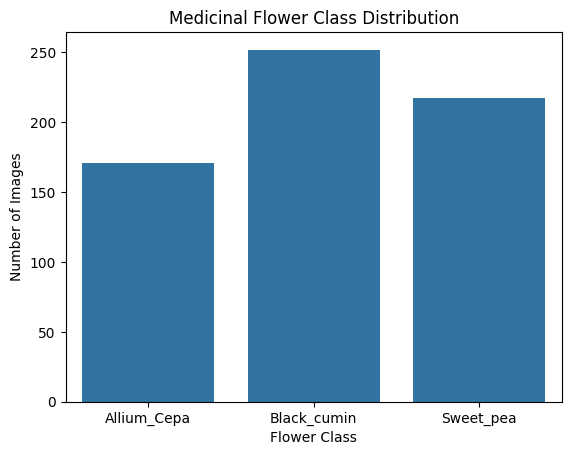

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="label", data=df)

plt.title("Medicinal Flower Class Distribution")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")

plt.show()

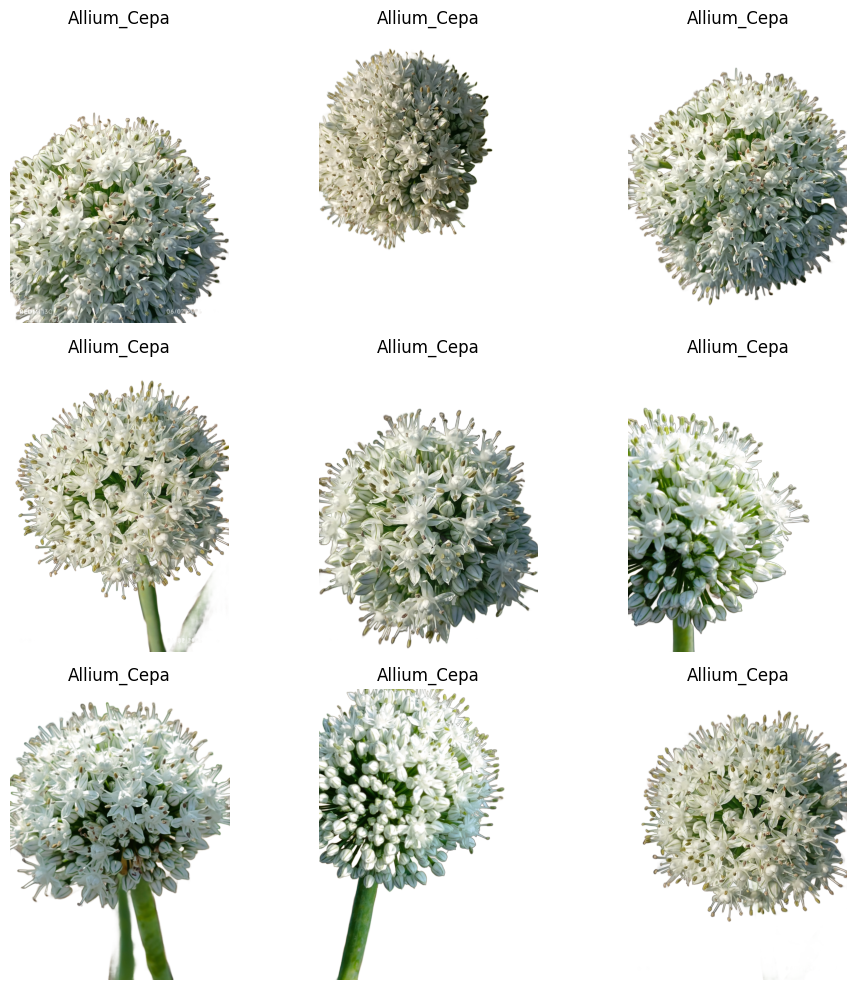

In [45]:
#open image
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img_path = df.iloc[i]["image_path"]
    label = df.iloc[i]["label"]

    image = Image.open(img_path)

    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [46]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 512
Validation: 64
Test: 64


In [47]:
class_to_idx = {
    "Allium_Cepa": 0,
    "Black_cumin": 1,
    "Sweet_pea": 2
}

train_df["label_idx"] = train_df["label"].map(class_to_idx)
val_df["label_idx"] = val_df["label"].map(class_to_idx)
test_df["label_idx"] = test_df["label"].map(class_to_idx)

In [48]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [49]:
from torch.utils.data import Dataset
from PIL import Image

class FlowerDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label_idx"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [50]:
train_dataset = FlowerDataset(
    train_df,
    train_transform
)

val_dataset = FlowerDataset(
    val_df,
    val_transform
)

test_dataset = FlowerDataset(
    test_df,
    val_transform
)

In [51]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [59]:
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    3
)

model = model.to(device)

In [60]:
import torch
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=None)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    3
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


In [61]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    3
)

In [62]:
import torch

device = torch.device("cpu")

print(device)

cpu


In [63]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [64]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Loss: {running_loss / len(train_loader):.4f}"
    )

Epoch 1/5, Loss: 0.4913
Epoch 2/5, Loss: 0.2243
Epoch 3/5, Loss: 0.1153
Epoch 4/5, Loss: 0.0901
Epoch 5/5, Loss: 0.0504


In [65]:
import torch

num_epochs = 5

train_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    # -----------------
    # TRAINING
    # -----------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)

    # -----------------
    # VALIDATION
    # -----------------
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 0.1498 Train Acc: 95.70% Val Acc: 100.00%
Epoch [2/5] Train Loss: 0.1100 Train Acc: 95.51% Val Acc: 100.00%
Epoch [3/5] Train Loss: 0.0188 Train Acc: 99.22% Val Acc: 100.00%
Epoch [4/5] Train Loss: 0.0603 Train Acc: 98.24% Val Acc: 100.00%
Epoch [5/5] Train Loss: 0.0473 Train Acc: 98.63% Val Acc: 100.00%


In [67]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Labels:", len(all_labels))
print("Predictions:", len(all_predictions))

Labels: 64
Predictions: 64


In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Precision     : {precision * 100:.2f}%")
print(f"Recall        : {recall * 100:.2f}%")
print(f"F1 Score      : {f1 * 100:.2f}%")

Test Accuracy : 100.00%
Precision     : 100.00%
Recall        : 100.00%
F1 Score      : 100.00%


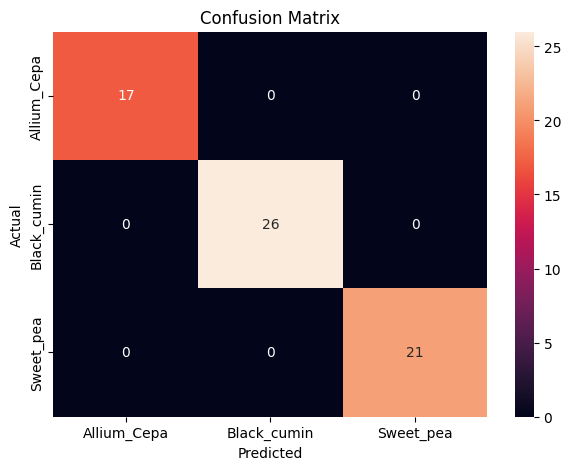

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

class_names = [
    "Allium_Cepa",
    "Black_cumin",
    "Sweet_pea"
]

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()